In [26]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7, # figure.titlesize,
    'legend.title_fontsize' : 5
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import helper_functions



In [27]:

# --- INIT ---


# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)


# settings
mesor_frac_thresh = 0.9
mesor_effect_thresh = 0.3 / np.log10(np.e)
amp_frac_thresh = 0.9
amp_effect_thresh = 0.2 / np.log10(np.e)
acrophase_frac_thresh = 0.1
acrophase_effect_thresh = 3 * (np.pi / 12.0)
frac_circadian_samples_crossing_zero_thresh = 0.1 # 0.1
num_waveform_samples = 300
use_log_prop_fft = True

# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_7' % head_folder
if not os.path.exists(folder_out):
    os.makedirs(folder_out)



In [28]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [29]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [30]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

# descriptions = list(adata.obs['description'].unique())
# clusters = list(adata.obs['cluster'].unique())

clusters = [0, 1, 2, 3]
cluster_cell_type_dict = dict(zip(clusters,['SMC','Fibroblast','Endothelial', 'Macrophage']))

descriptions = ['male aligned bmal1-ko', 
                'male misaligned bmal1-control', 
                'female aligned bmal1-ko', 
                'female misaligned bmal1-control', 
                'male aligned bmal1-control', 
                'female aligned bmal1-control']

print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)







Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3]


In [31]:
unique_zt = [0,6,12,18]
cluster = 0
zt = 12
description = 'male aligned bmal1-control'

bool_1 = adata.obs['description'] == description
bool_2 = adata.obs['cluster'] == cluster
bool_3 = adata.obs['zt'] == zt
adata = adata[bool_1 & bool_2 & bool_3]
unique_batches = adata.obs['batch'].unique()
adata = adata[adata.obs['batch'] == unique_batches[0]]
adata      
        
        
        

View of AnnData object with n_obs × n_vars = 4476 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [32]:
# --- PREP ---

adata.var['prop'] = np.array(np.sum(adata.X,axis=0)).flatten() / np.sum(adata.obs['lib_size'])
if 'log_L' not in adata.obs:
    adata.obs['log_L'] = np.array(np.log(adata.obs['lib_size']))
adata


/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_45517/1830430326.py:3: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['prop'] = np.array(np.sum(adata.X,axis=0)).flatten() / np.sum(adata.obs['lib_size'])


AnnData object with n_obs × n_vars = 4476 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster', 'log_L'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'prop'
    obsm: 'X_scVI', 'X_scVI_umap'

In [33]:
# --- SET PARAMS ---

adata = adata
folder_out = '%s/desktop/test' % (head_folder)
use_nb = False
log_mean_log_disp_coef=None
lr = 1e-1
num_gene_samples = 10
num_bf_est_gene_samples = 5
vi_max_epochs = 300
vi_print_epoch_loss = True
vi_improvement_window = 5
vi_convergence_criterion = 1e-3



In [34]:
def compute_ll_mat(X,
					log_L,
					gene_log_alpha,
					gene_log_beta,
					gene_min_log_prop,
					gene_max_log_prop,
					num_gene_samples,
					use_nb,
					log_mean_log_disp_coef):


	# ** get the gene alpha and beta's ** 
	gene_alpha = torch.exp(gene_log_alpha) # [num_genes]
	gene_beta = torch.exp(gene_log_beta) # [num_genes]

	#  ** sample gene proportions: [num_gene_samples x num_genes] ** 
	gene_dist = torch.distributions.beta.Beta(gene_alpha, gene_beta)
	gene_log_prop_sampled = gene_dist.rsample((num_gene_samples,)) 


	# ** scale by the min and max log props for each gene: [num_gene_samples x num_genes] **
	gene_log_prop_sampled = gene_log_prop_sampled * (gene_max_log_prop.unsqueeze(0) - gene_min_log_prop.unsqueeze(0)) + gene_min_log_prop.unsqueeze(0) # put in [min to max prop for each gene]


	# **  get the cell_gene_log_mean (expected log prop scaled by the library size): [num_cells x num_gene_samples x num_genes] ** 
	cell_gene_log_mean = gene_log_prop_sampled.unsqueeze(0) + log_L.unsqueeze(1).unsqueeze(2)
	cell_gene_mean = torch.exp(cell_gene_log_mean)

	#  ** compute the MC expected log likelihood for gene: # [num_gene_samples x num_cells x num_cell_samples x num_genes] ** 
	gene_X_reshaped = X.unsqueeze(1)
	if use_nb:
		ll_mat = objective_functions.compute_nb_ll(gene_X_reshaped,
		cell_gene_log_prop_sampled,
		cell_gene_log_mean,
		log_mean_log_disp_coef)
	else:
		ll_mat = torch.distributions.poisson.Poisson(cell_gene_mean).log_prob(gene_X_reshaped)

	return ll_mat



In [35]:









def run(adata, folder_out,
    use_nb = True,
    log_mean_log_disp_coef=None,
    lr = 1e-1,
    num_gene_samples = 1,
    vi_max_epochs = 300,
    vi_print_epoch_loss = True,
    vi_improvement_window = 5,
    vi_convergence_criterion = 1e-3,
    **kwargs):



    # --- MAKE FOLDER OUT ---
    if not os.path.exists(folder_out):
        os.makedirs(folder_out)



    # --- GET THE CONFIG DICT AND WRITE ---

    # ** get **
    config_dict = locals()
    del config_dict['adata']
    del config_dict['folder_out']

    # ** write **
    config_path = "%s/config.txt" % folder_out
    with open(config_path, "wb") as file_obj:
        file_obj.write(str(config_dict).encode())




    # --- COMPUTE THE GENE PSEUDOBULK PROP'S IF NOT ALREADY IN THERE ---
    if 'prop' not in adata.var:
        adata.var['prop'] = np.array(np.sum(adata.X,axis=0)).flatten() / np.sum(adata.obs['lib_size'])


    # --- ADD LOG_L IF NOT ALREADY IN THERE ---
    if 'log_L' not in adata.obs:
        adata.obs['log_L'] = np.array(np.log(adata.obs['lib_size']))



    # # --- GET RID OF GENES THAT HAVE ZERO PROP ---
    # adata = adata[:,adata.var['prop'] > 0]


    # --- IF use_nb = True and no coefficients supplied, ESTIMATE THE COEFFICIENTS ---
    if use_nb and log_mean_log_disp_coef is None:
        mean_disp_init_coef = [-4,-0.2]
        mean_disp_log10_prop_bin_marks = list(np.linspace(-7,-1,30))
        mean_disp_max_num_genes_per_bin = 50
        log_mean_log_disp_coef = estimate_mean_disp_relationship.estimate_mean_disp_relationship(adata, mean_disp_init_coef, mean_disp_log10_prop_bin_marks, mean_disp_max_num_genes_per_bin,min_log_disp=-10,max_log_disp=10)
        log_mean_log_disp_coef = torch.Tensor(log_mean_log_disp_coef)

        # ** write out **
        mean_disp_param_folder_out = "%s/mean_disp_param" % folder_out
        if not os.path.exists(mean_disp_param_folder_out):
            os.makedirs(mean_disp_param_folder_out)
        mean_disp_fit_coef_fileout = '%s/log_mean_log_disp_poly_coef.txt' % (mean_disp_param_folder_out)
        np.savetxt(mean_disp_fit_coef_fileout,log_mean_log_disp_coef.detach().numpy())




        
    # --- GET THE GENE MIN AND MAX'S ---

    # set the max amplitude
    max_amp = 1.5 / np.log10(np.e)

    # get the gene pseudobulk log prop's
    gene_prop = np.array(adata.var['prop'])
    gene_mean_log_prop = np.log(gene_prop)
    min_nonzero_log_prop = np.log(np.min(gene_prop[gene_prop > 0]))
    gene_mean_log_prop[gene_prop == 0] = min_nonzero_log_prop

    # compute the min and max log props
    # gene_min_log_prop = -9 / np.log10(np.e) * np.ones(gene_mean_log_prop.shape)
    # gene_max_log_prop = -1 / np.log10(np.e) * np.ones(gene_mean_log_prop.shape)
    gene_min_log_prop = gene_mean_log_prop - (max_amp / 2)
    gene_max_log_prop = gene_mean_log_prop + (max_amp / 2)
    gene_min_log_prop = torch.Tensor(gene_min_log_prop)
    gene_max_log_prop = torch.Tensor(gene_max_log_prop)




    # --- SET THE PRIORS ON THE BETA DISTRIBUTIONS ---

    prior_gene_alpha = torch.ones((adata.shape[1]))
    prior_gene_beta = torch.ones((adata.shape[1]))




        
        
        




    # --- GET X and log_L TENSOR ---

    try:
        X = torch.Tensor(np.array(adata.X.todense()))
    except:
        X = torch.Tensor(adata.X.todense())


    log_L = torch.log(torch.Tensor(np.array(adata.obs['lib_size'])))





    
    # --- INITIALIZE THE BETA DISTRIBUTION PARAMETERS AT EACH TIME POINT ----

    # init
    gene_log_alpha = torch.log(torch.ones((adata.shape[1])))
    gene_log_beta = torch.log(torch.ones((adata.shape[1])))

    # make parameters
    gene_log_alpha = torch.nn.Parameter(gene_log_alpha,requires_grad=True)
    gene_log_beta = torch.nn.Parameter(gene_log_beta,requires_grad=True)





    # In[24]:


    # --- TRAIN ---

    # ** make subfolder out **
    waveform_est_folder_out = "%s/waveform_est" % folder_out
    if not os.path.exists(waveform_est_folder_out):
        os.makedirs(waveform_est_folder_out)
    if not os.path.exists("%s/params" % waveform_est_folder_out):
        os.makedirs("%s/params" % waveform_est_folder_out)


    # ** init opt **
    optimizer = torch.optim.Adam([gene_log_alpha,gene_log_beta], lr = lr)


    # ** train **
    elbo_losses, kl_losses, ll_losses = [], [], []
    loss_percent_differences = []
    for epoch in range(0,vi_max_epochs):

        # ** zero grad **
        optimizer.zero_grad()

        # ** get the LL mat [num_gene_samples x num_cells x num_genes **
        cell_gene_ll_mat = compute_ll_mat(X,
            log_L,
            gene_log_alpha,
            gene_log_beta,
            gene_min_log_prop,
            gene_max_log_prop,
            num_gene_samples,
            use_nb,
            log_mean_log_disp_coef)


        # ** compute the gene MC estimate of the LL: [num_genes] **
        gene_mc_ll = torch.mean(torch.sum(cell_gene_ll_mat,dim=0),dim=0)

        # for each gene, compute the KL divergence
        prior_gene_dist = torch.distributions.beta.Beta(torch.ones(gene_log_alpha.shape),torch.ones(gene_log_beta.shape))
        gene_dist = torch.distributions.beta.Beta(torch.exp(gene_log_alpha),torch.exp(gene_log_beta))
        gene_kl = torch.distributions.kl_divergence(prior_gene_dist,gene_dist) # [num_grid_points x num_genes]
        gene_kl = torch.sum(gene_kl,dim=0)

        # compute the loss
        gene_loss = gene_kl - gene_mc_ll
        loss = torch.mean(gene_loss)

        # ** add epoch loss to list **
        elbo_losses.append(loss.item())
        kl_losses.append(torch.mean(gene_kl).item())
        ll_losses.append(torch.mean(gene_mc_ll).item())




        # ** pass backward **
        loss.backward()

        # ** step **
        optimizer.step()


        # ** write parameters at epoch to file **
        fileout = "%s/params/%s.pt" % (waveform_est_folder_out,epoch)
        param_dict = {"gene_log_alpha" : gene_log_alpha, "gene_log_beta" : gene_log_beta}
        torch.save(param_dict, fileout)


        # ** print loss **
        if vi_print_epoch_loss:
            print("Iter: %s; ELBO %s: E[LL]: %s; KL: %s" % (epoch, round(loss.item(),3), round(torch.mean(gene_mc_ll).item(),3), round(torch.mean(gene_kl).item(),3)))

        # ** calculate loss percentage improvement **
        if epoch >= 2 * vi_improvement_window:
            loss_percent_improvement =  1 - (np.mean(elbo_losses[epoch-vi_improvement_window:]) / np.mean(elbo_losses[epoch - (2 * vi_improvement_window):epoch-vi_improvement_window]))
            loss_percent_differences.append(loss_percent_improvement)
            if vi_print_epoch_loss:
                print("Improvement: %s" % loss_percent_improvement)

        # ** check if we should stop training **
        if (epoch >= 2 * vi_improvement_window) and (loss_percent_improvement <= vi_convergence_criterion):
            print("Loss converged and stopping")
            break





    # ** load optimal flat parameters **
    opt_gene_param_dict_unprepped = torch.load('%s/params/%s.pt' % (waveform_est_folder_out, np.argmin(elbo_losses)))
    opt_gene_log_alpha, opt_gene_log_beta = opt_gene_param_dict_unprepped['gene_log_alpha'], opt_gene_param_dict_unprepped['gene_log_beta']
    opt_gene_alpha, opt_gene_beta = torch.exp(opt_gene_log_alpha.detach()), torch.exp(opt_gene_log_beta.detach())



    # ** write the loss list out **

    # total loss
    fileout = '%s/loss.txt' % (waveform_est_folder_out)
    elbo_losses = list(map(lambda x: str(x), elbo_losses))
    with open(fileout, "wb") as file_obj:
        file_obj.write("\n".join(elbo_losses).encode())

    # KL loss
    fileout = '%s/kl_loss.txt' % (waveform_est_folder_out)
    kl_losses = list(map(lambda x: str(x), kl_losses))
    with open(fileout, "wb") as file_obj:
        file_obj.write("\n".join(kl_losses).encode())

    # log prop loss
    fileout = '%s/ll_loss.txt' % (waveform_est_folder_out)
    ll_losses = list(map(lambda x: str(x), ll_losses))
    with open(fileout, "wb") as file_obj:
        file_obj.write("\n".join(ll_losses).encode())





    # --- WRITE RESULTS OUT ---



    # write out the gene min and max
    min_max_fileout = '%s/log_min_max.tsv' % folder_out # % (folder_out)
    min_max_df = pd.DataFrame()
    min_max_df['gene'] = np.array(adata.var_names)
    min_max_df['log_min'] = np.array(gene_min_log_prop)
    min_max_df['log_max'] = np.array(gene_max_log_prop)
    min_max_df = min_max_df.set_index('gene')
    min_max_df.to_csv(min_max_fileout,sep='\t')

    # write out the gene log alpha
    gene_param_log_alpha_fileout = '%s/gene_log_alpha.tsv' % folder_out # % (folder_out)
    gene_param_log_alpha_df = pd.DataFrame()
    gene_param_log_alpha_df['log_alpha'] = opt_gene_log_alpha.detach().numpy()
    gene_param_log_alpha_df['gene'] = np.array(adata.var_names)
    gene_param_log_alpha_df = gene_param_log_alpha_df.set_index('gene')
    gene_param_log_alpha_df.to_csv(gene_param_log_alpha_fileout,sep='\t')

    # write out the gene log beta
    gene_param_log_beta_fileout = '%s/gene_log_beta.tsv' % folder_out # % (folder_out)
    gene_param_log_beta_df = pd.DataFrame()
    gene_param_log_beta_df['log_beta'] = opt_gene_log_beta.detach().numpy()
    gene_param_log_beta_df['gene'] = np.array(adata.var_names)
    gene_param_log_beta_df = gene_param_log_beta_df.set_index('gene')
    gene_param_log_beta_df.to_csv(gene_param_log_beta_fileout,sep='\t')

    
    
    
    


In [37]:
run(adata, folder_out,
	use_nb = False,
	log_mean_log_disp_coef=None,
	lr = 1e-2,
	num_waveform_est_gene_samples = 3,
	vi_max_epochs = 300,
	vi_print_epoch_loss = True,
	vi_improvement_window = 5,
	vi_convergence_criterion = 1e-3)




/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_45517/1004835696.py:76: RuntimeWarning: divide by zero encountered in log
  gene_mean_log_prop = np.log(gene_prop)


Iter: 0; ELBO 2684.86: E[LL]: -2684.86; KL: 0.0
Iter: 1; ELBO 2791.646: E[LL]: -2786.346; KL: 5.3
Iter: 2; ELBO 2673.059: E[LL]: -2669.917; KL: 3.143
Iter: 3; ELBO 2647.071: E[LL]: -2642.648; KL: 4.423
Iter: 4; ELBO 2834.031: E[LL]: -2827.538; KL: 6.493
Iter: 5; ELBO 2581.776: E[LL]: -2575.005; KL: 6.771
Iter: 6; ELBO 2676.968: E[LL]: -2670.641; KL: 6.327
Iter: 7; ELBO 2535.155: E[LL]: -2528.719; KL: 6.435
Iter: 8; ELBO 2592.381: E[LL]: -2585.007; KL: 7.374
Iter: 9; ELBO 2721.951: E[LL]: -2713.496; KL: 8.454
Iter: 10; ELBO 2713.071: E[LL]: -2704.027; KL: 9.043
Improvement: 0.032738622976696274
Iter: 11; ELBO 2664.259: E[LL]: -2655.076; KL: 9.183
Improvement: 0.020286675919439
Iter: 12; ELBO 2707.106: E[LL]: -2697.776; KL: 9.33
Improvement: 0.010037788946921311
Iter: 13; ELBO 2557.955: E[LL]: -2548.13; KL: 9.824
Improvement: -0.0016774560269026129
Loss converged and stopping


(array([16., 14.,  7.,  9., 16.,  4.,  8.,  6.,  7., 13.]),
 array([-4.195452 , -4.0511975, -3.9069426, -3.762688 , -3.618433 ,
        -3.4741783, -3.3299236, -3.1856687, -3.041414 , -2.897159 ,
        -2.7529044], dtype=float32),
 <BarContainer object of 10 artists>)

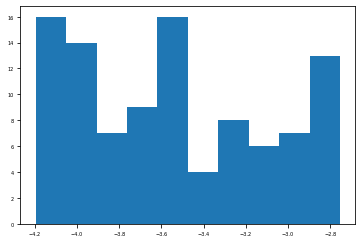

In [38]:
log_alpha = torch.Tensor(np.array([0.003880938]))
log_beta = torch.Tensor(np.array([0.021613002]))
samples = torch.distributions.beta.Beta(torch.exp(log_alpha),torch.exp(log_beta)).sample((100,))
samples = samples.numpy().flatten()
log_min = -9.752471
log_max = -6.298593
samples = samples * (log_max - log_min) + log_min
samples = samples / np.log(10)

plt.hist(samples)



